## Libarys

In [130]:
import numpy as np
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path
from scipy.signal import welch
import re
from scipy.signal import resample
parent_dir = Path().resolve().parent
sys.path.append(str(parent_dir))

from utilities.preprocessing import Filtering
import mne

## Global variables

In [ ]:
EEG_CH_NAMES = [
    "Fp1", "Fp2",   # frontal pole
    "C3",  "C4",    # central
    "T5",  "T6",    # temporal (posterior)
    "Cz",  "Fz",    # occipital
    "F7",  "F8",    # temporal (anterior)
    "F3",  "F4",    # frontal
    "T3",  "T4",    # temporal (mid)
    "P3",  "P4"     # parietal
]

NUM_EPOCH = 35*3
EEG_FREQ = 125

## Generate Random Data and Mix the Signals

In [155]:
def load_multi_csv(csv_files, data_type=None):
    dfs = []
    for f in csv_files:
        # Extract finger name only
        # r'imp_con_(.*?)_grip_'
        match = re.search(r'flex_index_finger_(.*?)', f.stem)
        finger = match.group(1) if match else 'unknown'                

        if data_type == 'EEG':
            df = pd.read_csv(f, delimiter=',')    
            #df = pd.read_csv(f, delim_whitespace=True)
        else:
            df = pd.read_csv(f)
        df['finger'] = finger
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

path = r'C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\Nicklas_wrist_EMG\EEG'

sf = 'flex_index_finger_*.csv'
#sf = 'imp_con_*_grip_*.csv'

# For EMG
EEG_data_dir = Path(path)
csv_files = list(EEG_data_dir.glob(sf))          # Find path to all files of this name

EEG_raw_df = load_multi_csv(csv_files)
EEG_data = EEG_raw_df.iloc[:, 1:17].to_numpy()

filt_ins = Filtering(fs=125)
notch = filt_ins.notch(EEG_data)
X, sos = filt_ins.butter_bandpass(notch, lowcut = 2, highcut = 30)


In [217]:
path = r'C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\Nicklas_wrist_EMG\EEG\blink_tyk_synk_experiment_2025-11-28 15-17-19.csv'
#path = r'C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\Nicklas_wrist_EMG\EEG\only_blink_experiment_2025-11-28 15-20-45.csv'

EEG_df = pd.read_csv(path, header=None)
EEG_data = EEG_df.iloc[:, 1:17].to_numpy()

filt_ins = Filtering(fs=125)
notch = filt_ins.notch(EEG_data)
X, sos = filt_ins.butter_bandpass(notch, lowcut = 2, highcut = 30)

time = np.arange(X.shape[0]) / 125

In [224]:
len(X) / 125 / 3

40.026666666666664

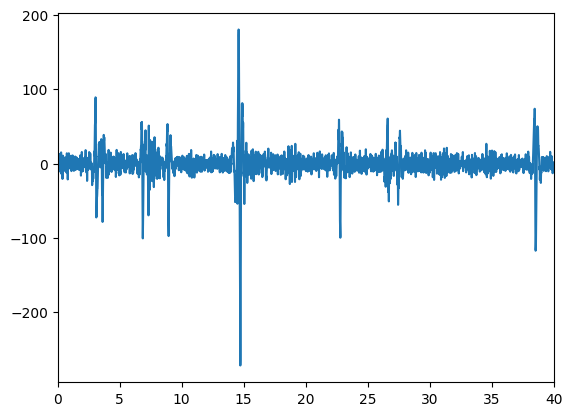

In [223]:
plt.plot(time, X[:, 0])
plt.xlim([0, 40])
plt.show()

## Resample

In [205]:
#total_time = NUM_EPOCH * 9               # total time in seconds. 9 sec per trial    
total_time = 10 * 4
real_fs = len(X) / (total_time)           # Total time in seconds 
target_len = int((len(X)) * (EEG_FREQ / real_fs))

EEG_resampled = resample(X, target_len, axis=0)

print(f'Total Time {total_time}\n Real fs: {real_fs} Hz\n Target len: {target_len}\n Original len: {len(X)}')
print(f'Resampled EEG {EEG_resampled.shape}')

Total Time 40
 Real fs: 125.075 Hz
 Target len: 5000
 Original len: 5003
Resampled EEG (5000, 16)


In [206]:
ch_names = [f"ch{i}" for i in range(X.shape[1])]
ch_types = ["eeg"] * EEG_resampled.shape[1]
sfreq = 125

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
raw = mne.io.RawArray(EEG_resampled.T, info)

Creating RawArray with float64 data, n_channels=16, n_times=5000
    Range : 0 ... 4999 =      0.000 ...    39.992 secs
Ready.


In [211]:
ica = mne.preprocessing.ICA(
    n_components=0.77,   # keep 99% variance OR use a fixed number like 15
    method='fastica',
    max_iter = 1000,
    random_state=97
)

reject = dict(eeg = 80)
ica.fit(raw, reject=None)

Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by explained variance: 2 components
Fitting ICA took 0.0s.


C:\Users\Bruger\AppData\Local\Temp\ipykernel_20344\107160551.py:9: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw, reject=None)


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,5 iterations on raw data (5000 samples)
ICA components,2
Available PCA components,16
Channel types,eeg
ICA components marked for exclusion,—


Creating RawArray with float64 data, n_channels=2, n_times=5000
    Range : 0 ... 4999 =      0.000 ...    39.992 secs
Ready.


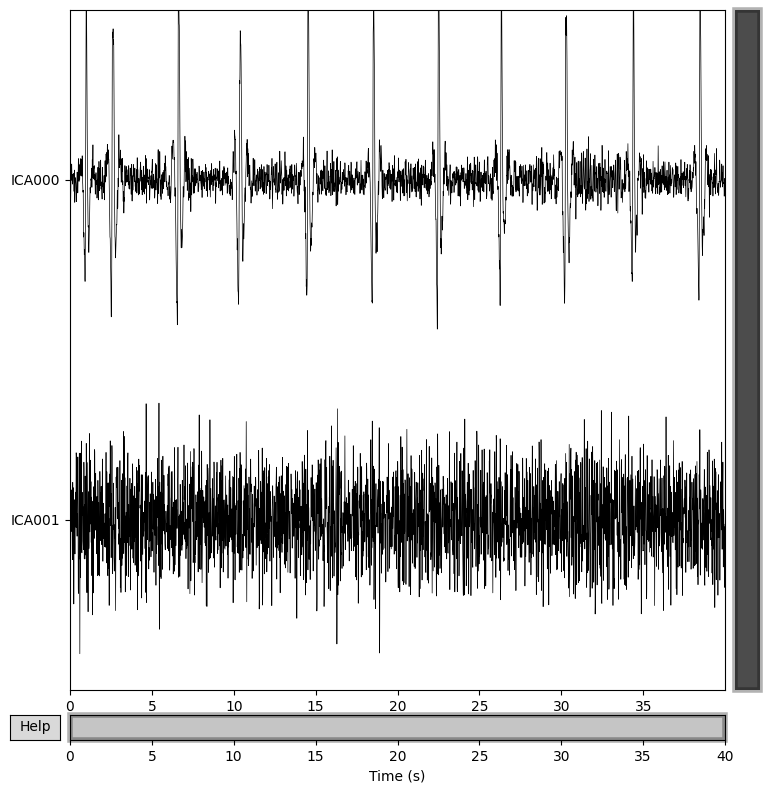

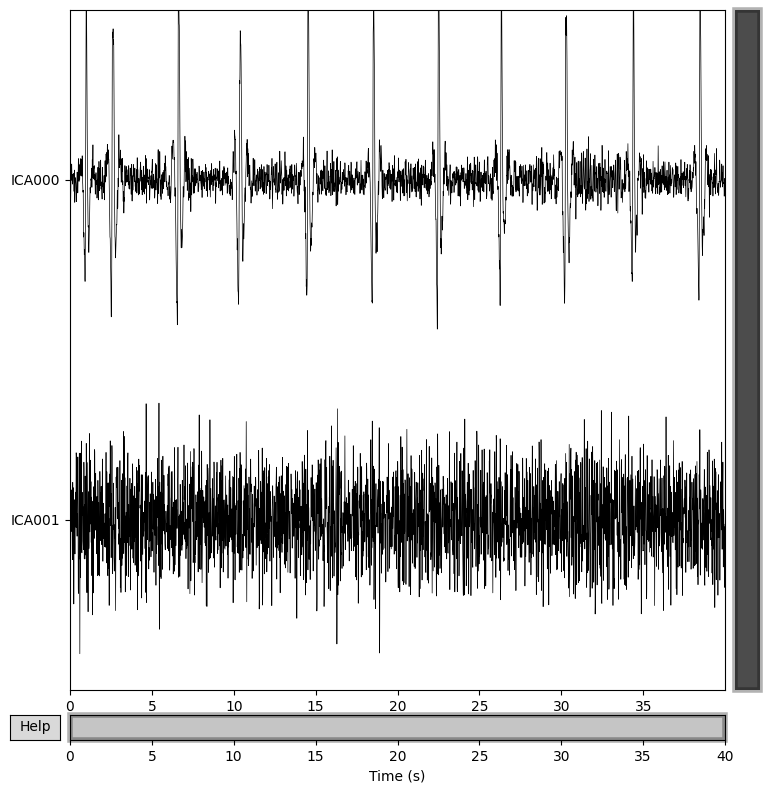

In [212]:
ica.plot_sources(inst = raw, picks = None, start = 0, stop = 40, theme = 'dark')


In [213]:
ica.exclude = [0]
raw_clean = ica.apply(raw.copy())

Applying ICA to Raw instance
    Transforming to ICA space (2 components)
    Zeroing out 1 ICA component
    Projecting back using 16 PCA components


In [126]:
raw.get_data().shape[1] / 125

945.488

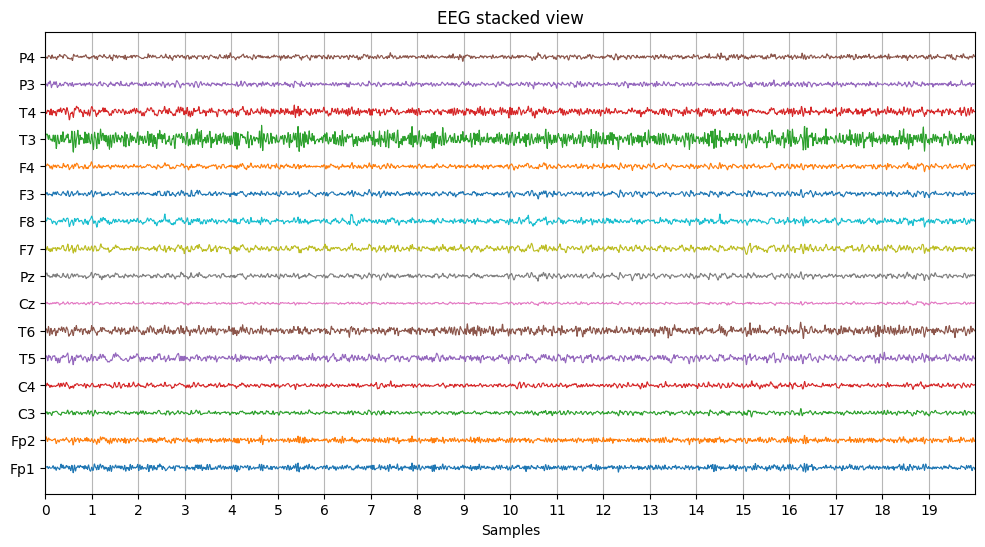

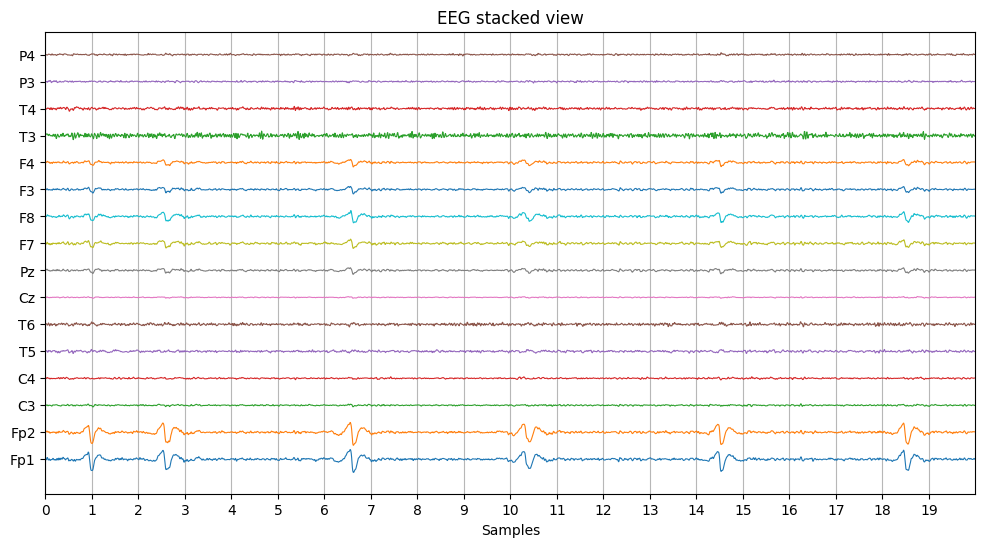

In [214]:
def plot_eeg_stack(data, sfreq, ch_names=None, seconds=40):
    """
    data : (samples, channels)  <-- your X or raw.get_data().T
    seconds : duration to show from start
    """

    n_samples = int(seconds * sfreq)
    data = data[:n_samples]
    time = np.arange(data.shape[0]) / sfreq

    yticks = []
    ylabels = []

    # scale channels to avoid overlap
    offset = np.max(np.abs(data)) * 2

    plt.figure(figsize=(12, 6))
    for i in range(data.shape[1]):
        y_offset = i * offset
        plt.plot(time, data[:, i] + y_offset, linewidth=0.8)

        yticks.append(y_offset)
        if ch_names:
            ylabels.append(ch_names[i])
        else:
            ylabels.append(f'ch{i}')

    plt.yticks(yticks, ylabels)
    plt.title("EEG stacked view")
    plt.xlabel("Samples")
    plt.grid(True, axis='x', alpha=0.9)
    plt.xticks(np.arange(0, 20, 1))
    plt.xlim([0, 20])
    plt.show()

plot_eeg_stack(raw_clean.get_data().T, sfreq=125, ch_names = EEG_CH_NAMES)
plot_eeg_stack(raw.get_data().T, sfreq=125, ch_names = EEG_CH_NAMES)

## EPOCHS

In [215]:
NUM_EPOCH = 10

EEG_samples_per_epoch = EEG_resampled.shape[0] // NUM_EPOCH      # Should be 30000
EEG_NUM_CH = 16

raw_data = raw.get_data().T
ica_data = raw_clean.get_data().T


raw_EEG_epoch = raw_data.reshape(NUM_EPOCH, EEG_samples_per_epoch, EEG_NUM_CH)
raw_EEG_epoch_mean = raw_EEG_epoch.mean(axis=0)

ica_EEG_epoch = ica_data.reshape(NUM_EPOCH, EEG_samples_per_epoch, EEG_NUM_CH)
ica_EEG_epoch_mean = ica_EEG_epoch.mean(axis=0)

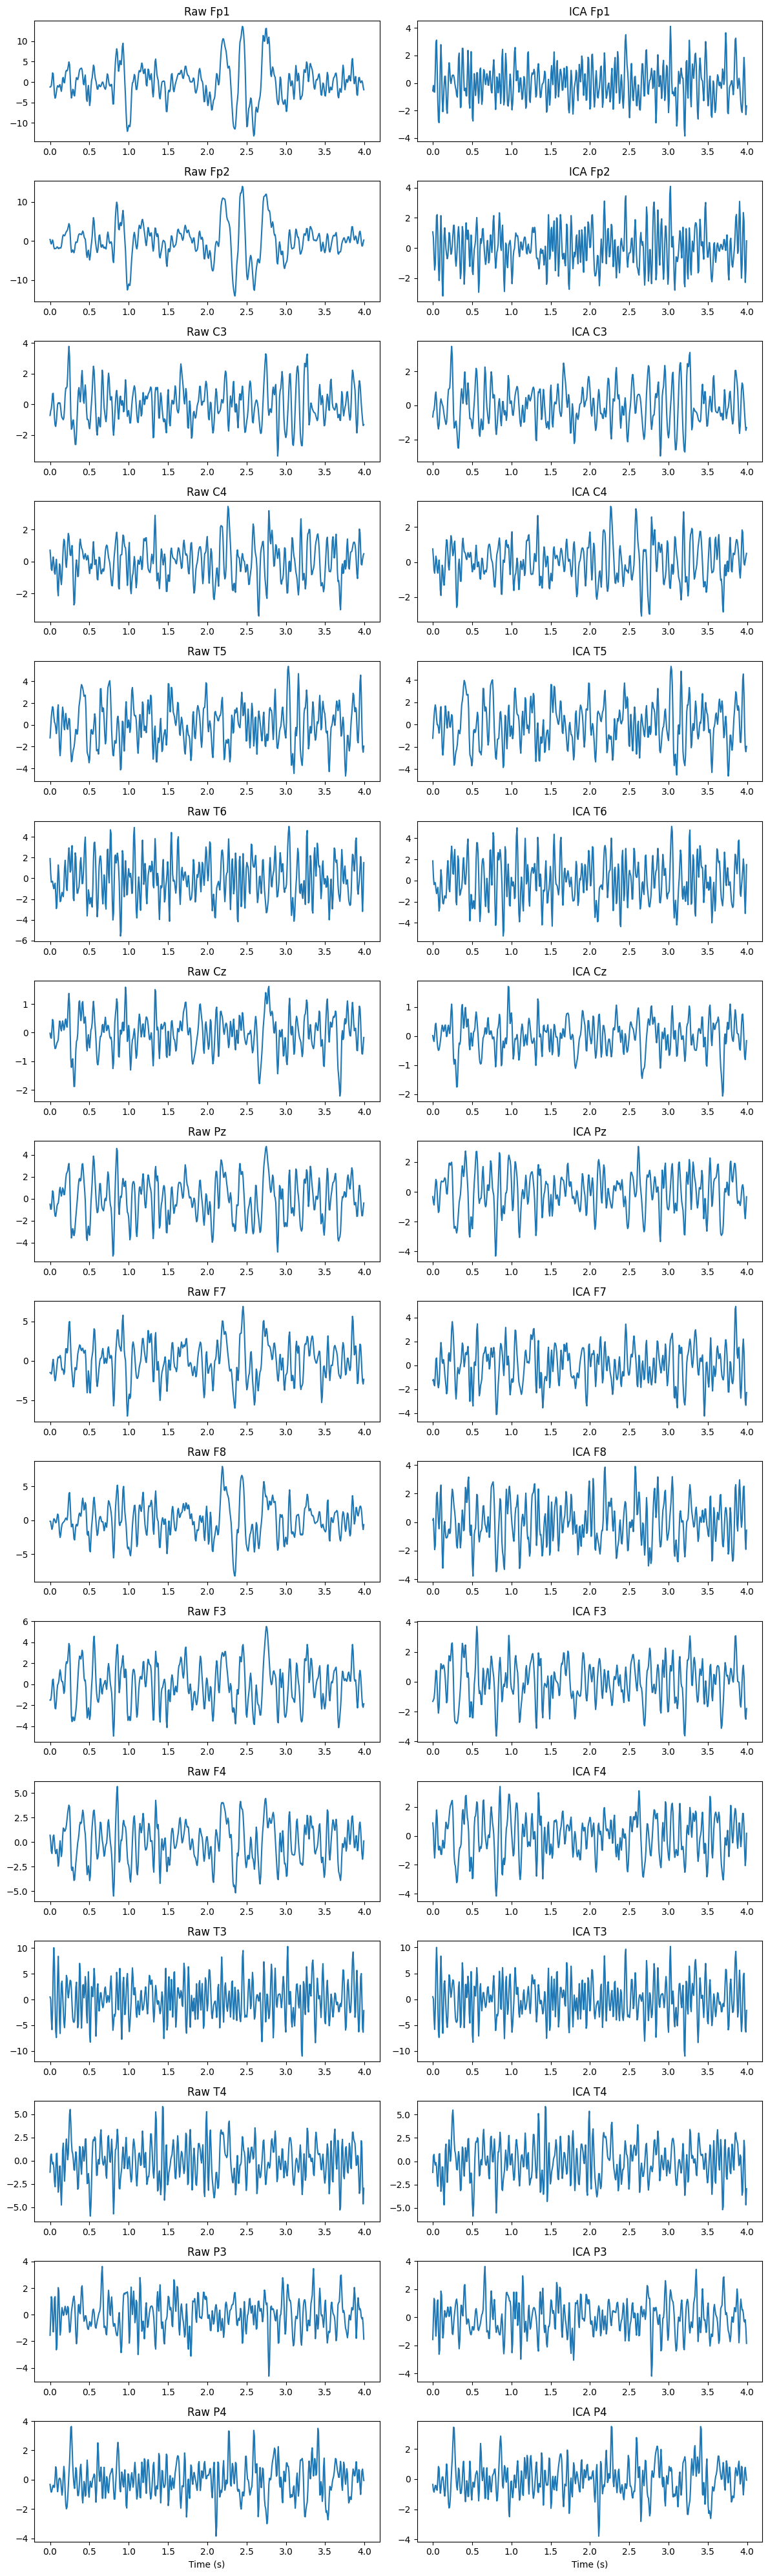

In [216]:
time = np.arange(raw_EEG_epoch_mean.shape[0]) / EEG_FREQ


fig, axes = plt.subplots(16, 2, figsize=(12,40))

for ch in range(16):
    # Left column (raw)
    axes[ch, 0].plot(time, raw_EEG_epoch_mean[:, ch])
    axes[ch, 0].set_title(f"Raw {EEG_CH_NAMES[ch]}")

    # Right column (ICA-cleaned)
    axes[ch, 1].plot(time, ica_EEG_epoch_mean[:, ch])
    axes[ch, 1].set_title(f"ICA {EEG_CH_NAMES[ch]}")


axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()